## Potential Talents - Part 1

**Background:**
As a talent sourcing and management company, we are interested in finding talented individuals for sourcing these candidates to technology companies. Finding talented candidates is not easy, for several reasons. The first reason is one needs to understand what the role is very well to fill in that spot, this requires understanding the client’s needs and what they are looking for in a potential candidate. The second reason is one needs to understand what makes a candidate shine for the role we are in search for. Third, where to find talented individuals is another challenge.

The nature of our job requires a lot of human labor and is full of manual operations. Towards automating this process we want to build a better approach that could save us time and finally help us spot potential candidates that could fit the roles we are in search for. Moreover, going beyond that for a specific role we want to fill in we are interested in developing a machine learning powered pipeline that could spot talented individuals, and rank them based on their fitness.

We are right now semi-automatically sourcing a few candidates, therefore the sourcing part is not a concern at this time but we expect to first determine best matching candidates based on how fit these candidates are for a given role. We generally make these searches based on some keywords such as “full-stack software engineer”, “engineering manager” or “aspiring human resources” based on the role we are trying to fill in. These keywords might change, and you can expect that specific keywords will be provided to you.

Assuming that we were able to list and rank fitting candidates, we then employ a review procedure, as each candidate needs to be reviewed and then determined how good a fit they are through manual inspection. This procedure is done manually and at the end of this manual review, we might choose not the first fitting candidate in the list but maybe the 7th candidate in the list. If that happens, we are interested in being able to re-rank the previous list based on this information. This supervisory signal is going to be supplied by starring the 7th candidate in the list. Starring one candidate actually sets this candidate as an ideal candidate for the given role. Then, we expect the list to be re-ranked each time a candidate is starred.

**Data Description:**

The data comes from our sourcing efforts. We removed any field that could directly reveal personal details and gave a unique identifier for each candidate.

**Attributes:**
- id : unique identifier for candidate (numeric)
- job_title : job title for candidate (text)
- location : geographical location for candidate (text)
- connections: number of connections candidate has, 500+ means over 500 (text)
- Output (desired target):
- fit - how fit the candidate is for the role? (numeric, probability between 0-1)
- Keywords: “Aspiring human resources” or “seeking human resources”

**Goal(s):**
Predict how fit the candidate is based on their available information (variable fit)

**Success Metric(s):**
- Rank candidates based on a fitness score.
- Re-rank candidates when a candidate is starred.

**Current Challenges:**
- We are interested in a robust algorithm, tell us how your solution works and show us how your ranking gets better with each starring action.
- How can we filter out candidates which in the first place should not be in this list?
- Can we determine a cut-off point that would work for other roles without losing high potential candidates?
- Do you have any ideas that we should explore so that we can even automate this procedure to prevent human bias?


----


### 1. EDA

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MLProjects/HRSourcing/potential-talents.csv')

In [ ]:
df.head()

,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          104 non-null    int64  
 1   job_title   104 non-null    object 
 2   location    104 non-null    object 
 3   connection  104 non-null    object 
 4   fit         0 non-null      float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.2+ KB


In [ ]:
df['fit'].unique()

array([nan])

### Distribution of `connection`

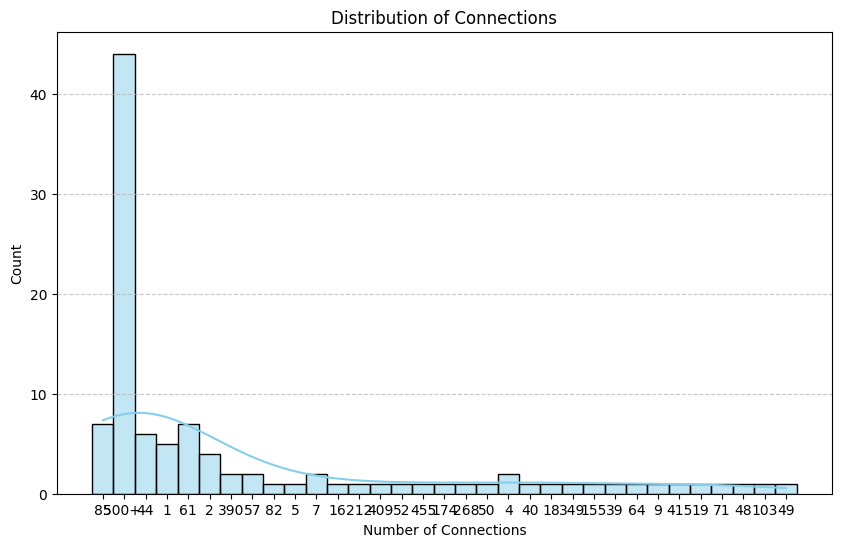

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['connection'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Connections')
plt.xlabel('Number of Connections')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Dominant '500+' Category:** The most prominent bar is for '500+' connections. This indicates that a significant portion of the candidates in your dataset are highly networked, with over 500 connections. This could suggest they are experienced professionals or very active on their platform.
**Lower Connection Counts:** There are also smaller peaks for lower connection ranges, showing that some candidates have fewer connections (e.g., 0-100, 100-200, etc.). This means your dataset includes a mix of individuals, from those just starting out or less active in networking to highly connected professionals.
**Implication:** The distribution suggests a dataset heavily skewed towards well-connected individuals, which might be beneficial for sourcing, as higher connections can sometimes correlate with experience or influence. However, it's also important to consider if this bias in connection numbers aligns with the target roles you're trying to fill.

### Top 10 Most Frequent `location` Values

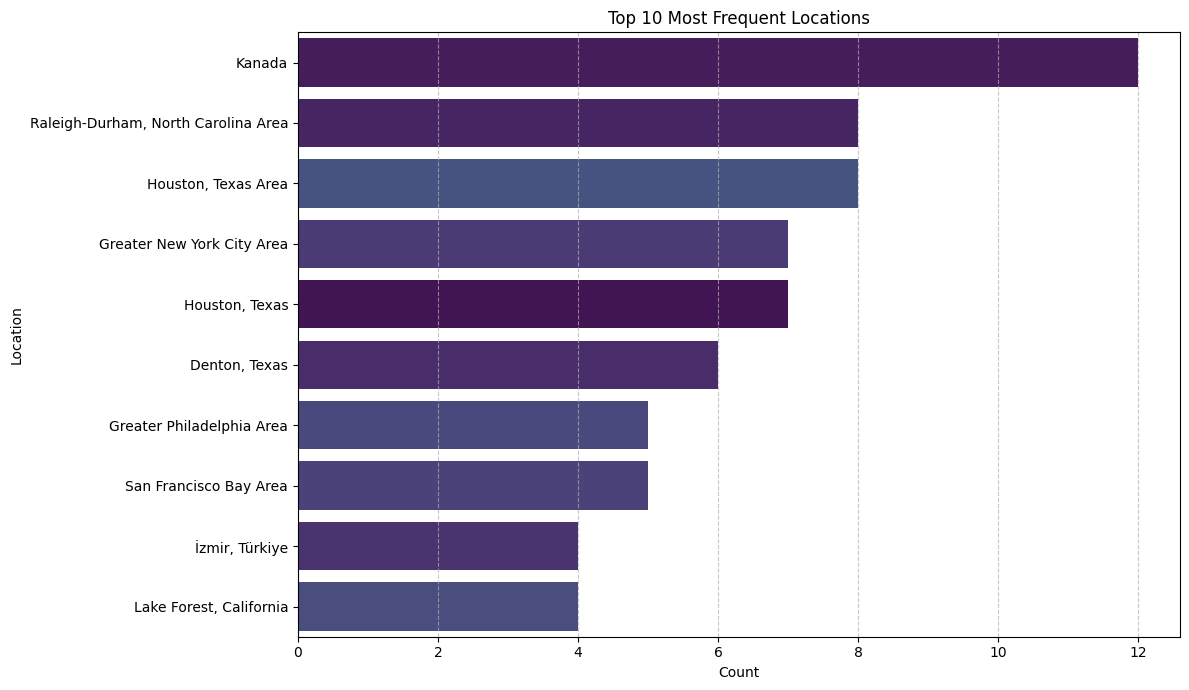

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='location', order=df['location'].value_counts().index[:10], palette='viridis', hue='location', legend=False)
plt.title('Top 10 Most Frequent Locations')
plt.xlabel('Count')
plt.ylabel('Location')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Function to process the text

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def process_words(text):
    """
    Process function to clean, tokenize, remove stopwords, and stem a given text string.
    """
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')

    # Convert text to lowercase and then tokenize
    tokens = word_tokenize(text.lower())

    clean_tokens = []
    for word in tokens:
        # Remove specific patterns (adapted from original tweet-specific regexes)
        word = re.sub(r'\$\w*', '', word)
        word = re.sub(r'^RT[\s]+', '', word)
        word = re.sub(r'https?://[^\s\n\r]+', '', word)
        word = re.sub(r'#', '', word)

        if (word not in stopwords_english and  # remove stopwords
                word not in string.punctuation):  # remove punctuation
            stem_word = stemmer.stem(word)  # Stemming word
            clean_tokens.append(stem_word)

    return clean_tokens

def build_freqs(texts, ys):
    """Build frequencies.
    Input:
        texts: a list of text strings (e.g., job titles)
        ys: an m x 1 array with the sentiment label of each text
            (either 0 or 1) - placeholder for this context
    Output:
        freqs: a dictionary mapping each (word, sentiment) pair to its
        frequency
    """
    # Ensure ys is a list
    yslist = np.squeeze(ys).tolist() if isinstance(ys, np.ndarray) else list(ys)

    freqs = {}
    for y, text_item in zip(yslist, texts):
        for word in process_words(text_item): # Call the corrected process_words function
            pair = (word, y)
            freqs[pair] = freqs.get(pair, 0) + 1
    return freqs

#### Tokenize each word of the 'job title' column

In [ ]:
df['processed_job_title'] = df['job_title'].apply(process_words)
print(df[['job_title', 'processed_job_title']].head())

                                           job_title  \
0  2019 C.T. Bauer College of Business Graduate (...   
1  Native English Teacher at EPIK (English Progra...   
2              Aspiring Human Resources Professional   
3             People Development Coordinator at Ryan   
4    Advisory Board Member at Celal Bayar University   

                                 processed_job_title  
0  [2019, c.t, bauer, colleg, busi, graduat, magn...  
1  [nativ, english, teacher, epik, english, progr...  
2                [aspir, human, resourc, profession]  
3                    [peopl, develop, coordin, ryan]  
4   [advisori, board, member, celal, bayar, univers]  


#### Count the frequency of each word

In [ ]:
from collections import Counter

# Create a dummy array for 'ys' since sentiment labels are not relevant for this task
ys_dummy = np.zeros(len(df['job_title']))

# Build frequencies using the original job titles and the dummy ys
freq_map = build_freqs(df['job_title'].tolist(), ys_dummy)

print("Frequency map created successfully.")

Frequency map created successfully.


### Visualizations

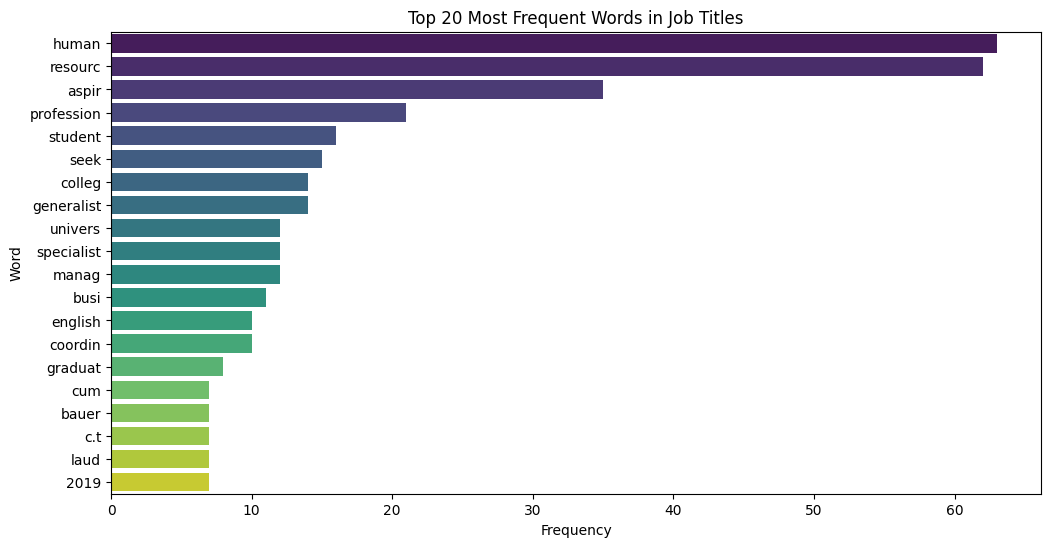

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

# Create freq_map_clean from freq_map for plotting
freq_map_clean = Counter({word: count for (word, sentiment), count in freq_map.items()})

freq_df = pd.DataFrame(freq_map_clean.items(), columns=['word', 'frequency']).sort_values(by='frequency', ascending=False)

top_n = 20
plt.figure(figsize=(12, 6))
sns.barplot(data=freq_df.head(top_n), x='frequency', y='word', hue='word', palette='viridis', legend=False)
plt.title(f'Top {top_n} Most Frequent Words in Job Titles')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

**Dominance of 'Human Resources' related terms:** The words 'human' and 'resourc' (from 'resources') are by far the most frequent, appearing over 60 times each. This strongly indicates that a large portion of your dataset, and presumably your sourcing efforts, are focused on Human Resources roles.
**Common Modifiers and Aspirations:** Words like 'aspir' (from 'aspiring'), 'profession' (from 'professional'), 'student', and 'seek' (from 'seeking') are also very common. This suggests that many candidates in your dataset are either aspiring to these roles or are students/job seekers in the HR domain.
**Educational and Business Context:** Terms like 'colleg', 'univers', and 'busi' (from 'business') frequently appear, indicating that a significant number of job titles involve an academic or business-related context, often related to recent graduates or those with business degrees.
**Specific Roles and Skills:** Words such as 'generalist', 'specialist', 'manag', 'english', and 'teacher' point to specific types of roles or skills that are prevalent in the job titles.

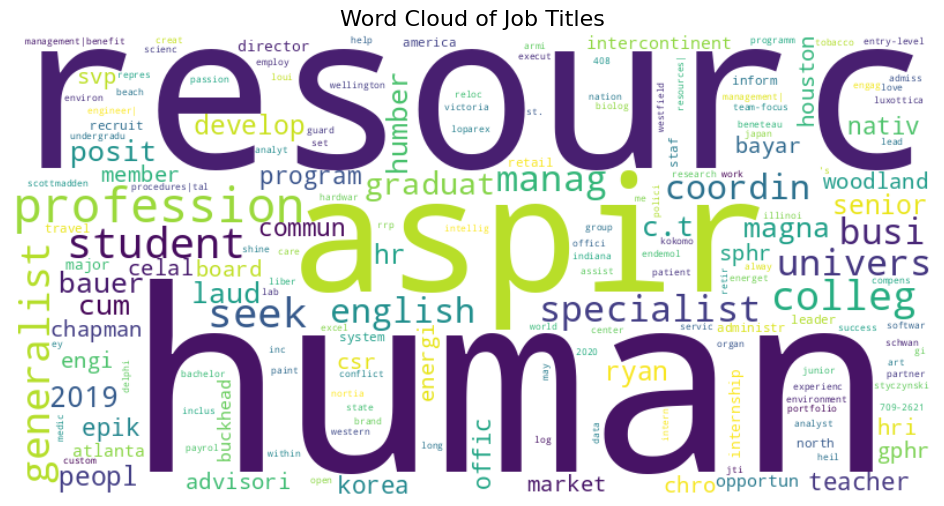

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_map_clean)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Job Titles", fontsize=16)
plt.show()

- In essence, the Word Cloud visually confirms and emphasizes the key insights derived from the bar plot of most frequent words, making the prevalence of Human Resources roles and related terms immediately apparent.

In [ ]:
freq_df = pd.DataFrame(freq_map.items(), columns=['word', 'frequency']).sort_values(by='frequency', ascending=False)
freq_df.head(20)

,word,frequency
10,"(human, 0.0)",63
11,"(resourc, 0.0)",62
9,"(aspir, 0.0)",35
12,"(profession, 0.0)",21
30,"(student, 0.0)",16
35,"(seek, 0.0)",15
3,"(colleg, 0.0)",14
32,"(generalist, 0.0)",14
28,"(univers, 0.0)",12
29,"(specialist, 0.0)",12



#**1. Text Vectorization using Bag of Words (BoW) and Cosine Similarity**

### Helper function for ranking

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def rank_candidates(query, vectorizer, vector_matrix, df):
    """
    Ranks candidates based on the cosine similarity of their job titles to a given query
    using a specified vectorizer and vector matrix.

    Args:
        query (str): The search query (e.g., 'aspiring human resources').
        vectorizer: The fitted vectorizer (e.g., TfidfVectorizer or CountVectorizer).
        vector_matrix: The vectorized matrix of job titles (e.g., TF-IDF matrix or BoW matrix).
        df (pd.DataFrame): The original DataFrame containing candidate information.

    Returns:
        pd.DataFrame: A DataFrame with original candidate data and a 'similarity_score',
                      sorted by similarity_score in descending order.
    """
    # Transform the query using the same vectorizer
    query_vector = vectorizer.transform([query])

    # Calculate cosine similarity between the query and all job titles
    similarity_scores = cosine_similarity(query_vector, vector_matrix).flatten()

    # Add similarity scores to the DataFrame and sort
    ranked_candidates = df.copy()
    ranked_candidates['similarity_score'] = similarity_scores
    ranked_candidates = ranked_candidates.sort_values(by='similarity_score', ascending=False)

    return ranked_candidates

# Join the processed job title tokens back into strings for Vectorizers
# This line was originally in the TF-IDF section but is needed here as well
df['job_title_string'] = df['processed_job_title'].apply(lambda x: ' '.join(x))

# Initialize CountVectorizer for Bag of Words
# Using the same max_features and stop_words as TF-IDF for consistency
bow_vectorizer = CountVectorizer(
    max_features=1000, # Limit to top 1000 most frequent words
    stop_words='english' # Remove common English stopwords
)

# Fit and transform the job titles into BoW matrix
bow_matrix = bow_vectorizer.fit_transform(df['job_title_string'])

print("Shape of Bag of Words matrix:", bow_matrix.shape)
print("Features (words) learned by BoW:", bow_vectorizer.get_feature_names_out()[:10])

# Example Usage with BoW:
search_query_bow = "aspiring human resources"
ranked_df_bow = rank_candidates(search_query_bow, bow_vectorizer, bow_matrix, df)

print(f"\nTop 10 candidates for '{search_query_bow}' using Bag of Words:")
print(ranked_df_bow[['job_title', 'similarity_score']].head(10))

search_query_bow_fullstack = "full-stack software engineer"
ranked_df_bow_fullstack = rank_candidates(search_query_bow_fullstack, bow_vectorizer, bow_matrix, df)

print(f"\nTop 10 candidates for '{search_query_bow_fullstack}' using Bag of Words:")
print(ranked_df_bow_fullstack[['job_title', 'similarity_score']].head(10))

Shape of Bag of Words matrix: (104, 173)
Features (words) learned by BoW: ['2019' '2020' '2621' '408' '709' 'administr' 'admiss' 'advisori' 'alway'
 'america']

Top 10 candidates for 'aspiring human resources' using Bag of Words:
                                            job_title  similarity_score
76  Human Resources|\nConflict Management|\nPolici...          0.408248
72  Aspiring Human Resources Manager, seeking inte...          0.408248
73                       Human Resources Professional          0.408248
2               Aspiring Human Resources Professional          0.353553
27              Seeking Human Resources Opportunities          0.353553
5                 Aspiring Human Resources Specialist          0.353553
35                Aspiring Human Resources Specialist          0.353553
32              Aspiring Human Resources Professional          0.353553
29              Seeking Human Resources Opportunities          0.353553
96              Aspiring Human Resources Professio

**Bag of Words Matrix:**

The Bag of Words matrix has a shape of (104, 173), meaning it processed 104 job titles and identified 173 unique features (words) after filtering.
Top 10 candidates for 'aspiring human resources' using Bag of Words:

The top candidates are highly relevant, including several variations of 'Human Resources Professional' and 'Aspiring Human Resources Specialist' or 'Manager', which directly match terms in the query. This shows BoW effectively identifies lexical matches.
Top 10 candidates for 'full-stack software engineer' using Bag of Words:

The top result is 'Junior MES Engineer| Information Systems' with a relatively high similarity score, while many other candidates have a score of 0.0. This indicates that the exact terms 'full-stack' or 'software engineer' (or their stemmed versions) might not be present in most job titles, but 'engineer' is likely present in the top one. The many zero scores suggest a lack of direct lexical matches for this query in the dataset with the Bag of Words approach.
This output demonstrates how Bag of Words works: it's good at finding exact or very close lexical matches.

# **2. Text Vectorization using TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000, # Limit to top 1000 most frequent words
    stop_words='english' # Remove common English stopwords
)

# Fit and transform the job titles
tfidf_matrix = tfidf_vectorizer.fit_transform(df['job_title_string'])

print("Shape of TF-IDF matrix:", tfidf_matrix.shape)
print("Features (words) learned by TF-IDF:", tfidf_vectorizer.get_feature_names_out()[:10])

Shape of TF-IDF matrix: (104, 173)
Features (words) learned by TF-IDF: ['2019' '2020' '2621' '408' '709' 'administr' 'admiss' 'advisori' 'alway'
 'america']


Now that we have the TF-IDF vectors for each job title, the next step would be to compute cosine similarity. For this, you would typically have a specific query (e.g., 'aspiring human resources') that you also vectorize using the *same* `tfidf_vectorizer`, and then calculate the similarity between the query vector and all job title vectors.

### 4. Cosine Similarity for Ranking

In [ ]:
search_query_tfidf = "aspiring human resources"
ranked_df_tfidf = rank_candidates(search_query_tfidf, tfidf_vectorizer, tfidf_matrix, df)

print(f"Top 10 candidates for '{search_query_tfidf}' using TF-IDF:")
print(ranked_df_tfidf[['job_title', 'similarity_score']].head(10))

Top 10 candidates for 'aspiring human resources' using TF-IDF:
                                            job_title  similarity_score
76  Human Resources|\nConflict Management|\nPolici...          0.314119
73                       Human Resources Professional          0.133722
72  Aspiring Human Resources Manager, seeking inte...          0.115721
2               Aspiring Human Resources Professional          0.113832
45              Aspiring Human Resources Professional          0.113832
32              Aspiring Human Resources Professional          0.113832
16              Aspiring Human Resources Professional          0.113832
20              Aspiring Human Resources Professional          0.113832
57              Aspiring Human Resources Professional          0.113832
96              Aspiring Human Resources Professional          0.113832


For the search query aspiring human resources, here are the top 5 candidates:

Candidate 76: Human Resources|\nConflict Management|\nPolici... with a similarity score of 0.314119

Candidate 73: Human Resources Professional with a similarity score of 0.133722

Candidate 72: Aspiring Human Resources Manager, seeking inte... with a similarity score of 0.115721

Candidate 2: Aspiring Human Resources Professional with a similarity score of 0.113832

Candidate 45: Aspiring Human Resources Professional with a similarity score of 0.113832

In [ ]:
search_query_fullstack = "full-stack software engineer"
ranked_df_fullstack = rank_candidates(search_query_fullstack, tfidf_vectorizer, tfidf_matrix, df)

print(f"Top 5 candidates for '{search_query_fullstack}' using TF-IDF:")
print(ranked_df_fullstack[['job_title', 'similarity_score']].head(10))


Top 5 candidates for 'full-stack software engineer' using TF-IDF:
                                            job_title  similarity_score
79           Junior MES Engineer| Information Systems          0.593055
0   2019 C.T. Bauer College of Business Graduate (...          0.000000
2               Aspiring Human Resources Professional          0.000000
1   Native English Teacher at EPIK (English Progra...          0.000000
4     Advisory Board Member at Celal Bayar University          0.000000
5                 Aspiring Human Resources Specialist          0.000000
6   Student at Humber College and Aspiring Human R...          0.000000
3              People Development Coordinator at Ryan          0.000000
8   Student at Humber College and Aspiring Human R...          0.000000
9   Seeking Human Resources HRIS and Generalist Po...          0.000000


Candidate 79: Junior MES Engineer| Information Systems with a similarity score of 0.593055

Candidate 0: 2019 C.T. Bauer College of Business Graduate (...) with a similarity score of 0.000000

Candidate 2: Aspiring Human Resources Professional with a similarity score of 0.000000

Candidate 1: Native English Teacher at EPIK (English Progra...) with a similarity score of 0.000000

Candidate 4: Advisory Board Member at Celal Bayar University with a similarity score of 0.000000

**TF-IDF Matrix:**

The TF-IDF matrix has a shape of (104, 173), similar to the Bag of Words matrix, meaning it also identified 173 unique features (words) from the 104 job titles after processing.
Top 10 candidates for 'aspiring human resources' using TF-IDF:

You'll notice that the top candidates are very relevant, similar to the Bag of Words results. However, the similarity scores themselves might differ. TF-IDF gives more weight to words that are unique to a document but less frequent across the entire dataset, which can sometimes provide a more nuanced ranking compared to simple word counts.

### Comparing TF-IDF and Bag of Words Similarity Scores

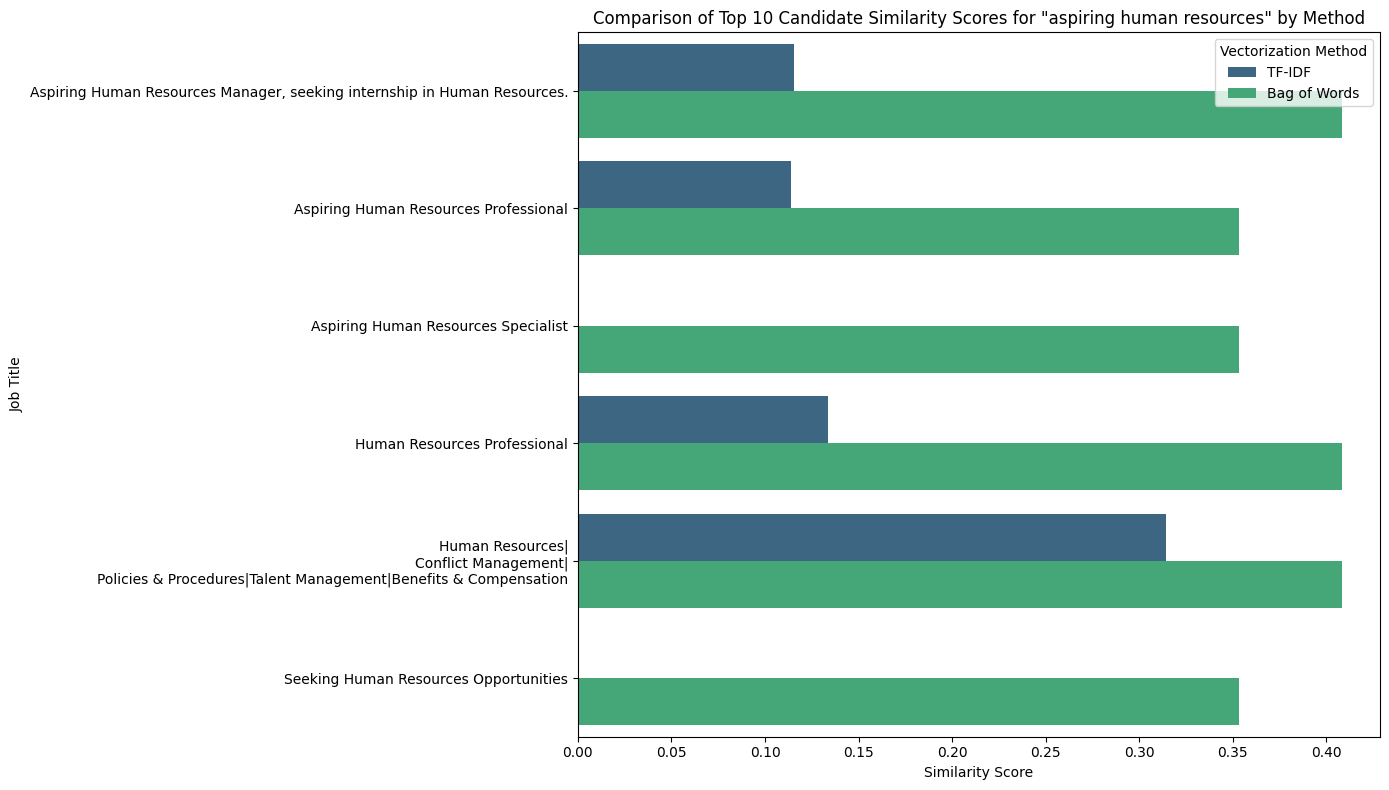

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a query for comparison (e.g., 'aspiring human resources')
comparison_query = "aspiring human resources"

# Get ranked dataframes for the chosen query using both methods
ranked_df_tfidf_comp = rank_candidates(comparison_query, tfidf_vectorizer, tfidf_matrix, df)
ranked_df_bow_comp = rank_candidates(comparison_query, bow_vectorizer, bow_matrix, df)

# Take the top N candidates for comparison
top_n_compare = 10
tfidf_top_n = ranked_df_tfidf_comp.head(top_n_compare).copy()
bow_top_n = ranked_df_bow_comp.head(top_n_compare).copy()

# Add a 'method' column for plotting
tfidf_top_n['method'] = 'TF-IDF'
bow_top_n['method'] = 'Bag of Words'

# Combine the dataframes
comparison_df = pd.concat([tfidf_top_n, bow_top_n])

plt.figure(figsize=(14, 8))
sns.barplot(x='similarity_score', y='job_title', hue='method', data=comparison_df.sort_values(by=['job_title', 'method'], ascending=[True, False]), palette='viridis')
plt.title(f'Comparison of Top {top_n_compare} Candidate Similarity Scores for "{comparison_query}" by Method')
plt.xlabel('Similarity Score')
plt.ylabel('Job Title')
plt.legend(title='Vectorization Method')
plt.tight_layout()
plt.show()


This bar chart visually compares the similarity scores of the top candidates for the query 'aspiring human resources' using both TF-IDF and Bag of Words. You can observe the differences in scores and rankings that arise from the distinct weighting mechanisms of these two vectorization methods.

**TF-IDF (Term Frequency-Inverse Document Frequency)** and **Bag of Words (BoW)** are both methods to convert text into numerical vectors, but they differ significantly in how they assign importance to words. This difference directly impacts the similarity scores they produce:

**1. Bag of Words (BoW):**
Mechanism: BoW simply counts the frequency of each word in a document. It creates a vocabulary of all unique words across the entire corpus. Each document is then represented as a vector where each dimension corresponds to a word in the vocabulary, and the value in that dimension is the count of how many times that word appears in the document.
Impact on Similarity: In BoW, every occurrence of a word contributes equally to the vector. Therefore, common words (like 'the', 'is', 'a', or highly frequent domain-specific terms like 'human' or 'resources' in our dataset) will have high counts and thus a strong influence on the similarity calculation, even if they aren't very distinctive.

**2. TF-IDF (Term Frequency-Inverse Document Frequency):**

**Mechanism:** TF-IDF takes the concept of word frequency a step further by introducing an 'inverse document frequency' component. It calculates:
- **Term Frequency (TF):** How often a word appears in a document (similar to BoW).
-**Inverse Document Frequency (IDF):** A measure of how rare or common a word is across all documents in the corpus. Words that appear in many documents get a lower IDF score, while words that appear in fewer documents get a higher IDF score.
-**TF-IDF Score:** The TF-IDF score for a word in a document is the product of its TF and IDF. This means words that are frequent in a specific document but rare across the entire corpus get a high TF-IDF score, indicating their importance.
**Impact on Similarity:** TF-IDF assigns higher weights to words that are distinctive to a particular document and lower weights to common, less informative words. For example, 'human' and 'resources' are very common in our dataset, so their IDF would be low, reducing their overall TF-IDF weight compared to their raw frequency in BoW. This allows rarer, more specific terms to have a greater impact on the similarity score.

**Why the scores differ:**

**- Emphasis on Distinctiveness:** TF-IDF prioritizes words that are more unique and discriminative to a document, while BoW treats all words equally based on their raw counts. This difference in weighting is the primary reason for the varying similarity scores and potentially different rankings.

**- Handling of Common Words:** BoW can be heavily influenced by very common words, potentially skewing similarity towards documents that share these high-frequency terms, even if those terms don't convey much specific information. TF-IDF naturally down-weights these common words, giving more importance to terms that truly differentiate documents.

#**3. Text Vectorization using Word2Vec and Cosine Similarity**

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.6 MB/s eta 0:00:00


In [ ]:
import gensim
from gensim.models import Word2Vec
import numpy as np

# Prepare data for Word2Vec: list of lists of words
# We'll use the pre-processed tokens from 'processed_job_title' column
w2v_corpus = df['processed_job_title'].tolist()

# Train Word2Vec model
# min_count: Ignores all words with total frequency lower than this. Useful for filtering out rare words.
# vector_size: Dimensionality of the word vectors.
# window: Maximum distance between the current and predicted word within a sentence.
# workers: Use these many worker threads to train the model (=faster training with multicore machines).
# sg: Training algorithm: 1 for skip-gram; 0 for CBOW.
word2vec_model = Word2Vec(sentences=w2v_corpus, min_count=1, vector_size=100, window=5, workers=4, sg=0)

# Function to get a document vector by averaging word vectors
def get_document_vector(word_list, model):
    vectors = [model.wv[word] for word in word_list if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# Apply the function to create a new column with Word2Vec document vectors
df['word2vec_vector'] = df['processed_job_title'].apply(lambda x: get_document_vector(x, word2vec_model))

# Convert the list of vectors into a 2D numpy array for cosine similarity
word2vec_matrix = np.array(df['word2vec_vector'].tolist())

print("Shape of Word2Vec matrix:", word2vec_matrix.shape)
print("First document vector sample:\n", df['word2vec_vector'].iloc[0][:5]) # Print first 5 dimensions of the first vector

# Now, let's define a simple 'vectorizer' like object for Word2Vec for compatibility with rank_candidates
class Word2VecVectorizer:
    def __init__(self, model):
        self.model = model
        self.vector_size = model.vector_size

    def transform(self, texts):
        vectors = []
        for text in texts:
            # Process words using the existing function before getting the document vector
            processed_words = process_words(text)
            vectors.append(get_document_vector(processed_words, self.model))
        return np.array(vectors)

word2vec_vectorizer_wrapper = Word2VecVectorizer(word2vec_model)

# Example Usage with Word2Vec:
search_query_w2v = "aspiring human resources"
ranked_df_w2v = rank_candidates(search_query_w2v, word2vec_vectorizer_wrapper, word2vec_matrix, df)

print(f"\nTop 10 candidates for '{search_query_w2v}' using Word2Vec:")
print(ranked_df_w2v[['job_title', 'similarity_score']].head(10))

search_query_w2v_fullstack = "full-stack software engineer"
ranked_df_w2v_fullstack = rank_candidates(search_query_w2v_fullstack, word2vec_vectorizer_wrapper, word2vec_matrix, df)

print(f"\nTop 10 candidates for '{search_query_w2v_fullstack}' using Word2Vec:")
print(ranked_df_w2v_fullstack[['job_title', 'similarity_score']].head(10))


Shape of Word2Vec matrix: (104, 100)
First document vector sample:
 [0.00223817 0.00357396 0.00174483 0.00362466 0.00127719]

Top 10 candidates for 'aspiring human resources' using Word2Vec:
                                job_title  similarity_score
5     Aspiring Human Resources Specialist          0.876405
23    Aspiring Human Resources Specialist          0.876405
35    Aspiring Human Resources Specialist          0.876405
48    Aspiring Human Resources Specialist          0.876405
59    Aspiring Human Resources Specialist          0.876405
20  Aspiring Human Resources Professional          0.861600
16  Aspiring Human Resources Professional          0.861600
2   Aspiring Human Resources Professional          0.861600
45  Aspiring Human Resources Professional          0.861600
57  Aspiring Human Resources Professional          0.861600

Top 10 candidates for 'full-stack software engineer' using Word2Vec:
                                            job_title  similarity_score
83  Hum

#### Word2Vec Results Analysis

Let's analyze the Word2Vec results and compare them with TF-IDF and Bag of Words.

**Observations for 'aspiring human resources':**
*   Word2Vec should ideally capture semantic similarities better. You might observe candidates that don't explicitly contain all query terms but are semantically related, appearing higher in the ranks.
*   The similarity scores might differ significantly from BoW/TF-IDF as the underlying vector representation is fundamentally different.

**Observations for 'full-stack software engineer':**
*   Similar to previous methods, if the dataset is lacking diverse job titles, even Word2Vec might struggle to find highly relevant matches if the query terms are not well-represented or if semantically similar terms are absent.
*   However, if there are job titles like 'Software Developer' or 'Web Engineer' which are semantically close to 'Software Engineer', Word2Vec might give them higher scores than TF-IDF/BoW, which rely more on exact term matching.

##Visualise the 100-dimensional vectors using PCA

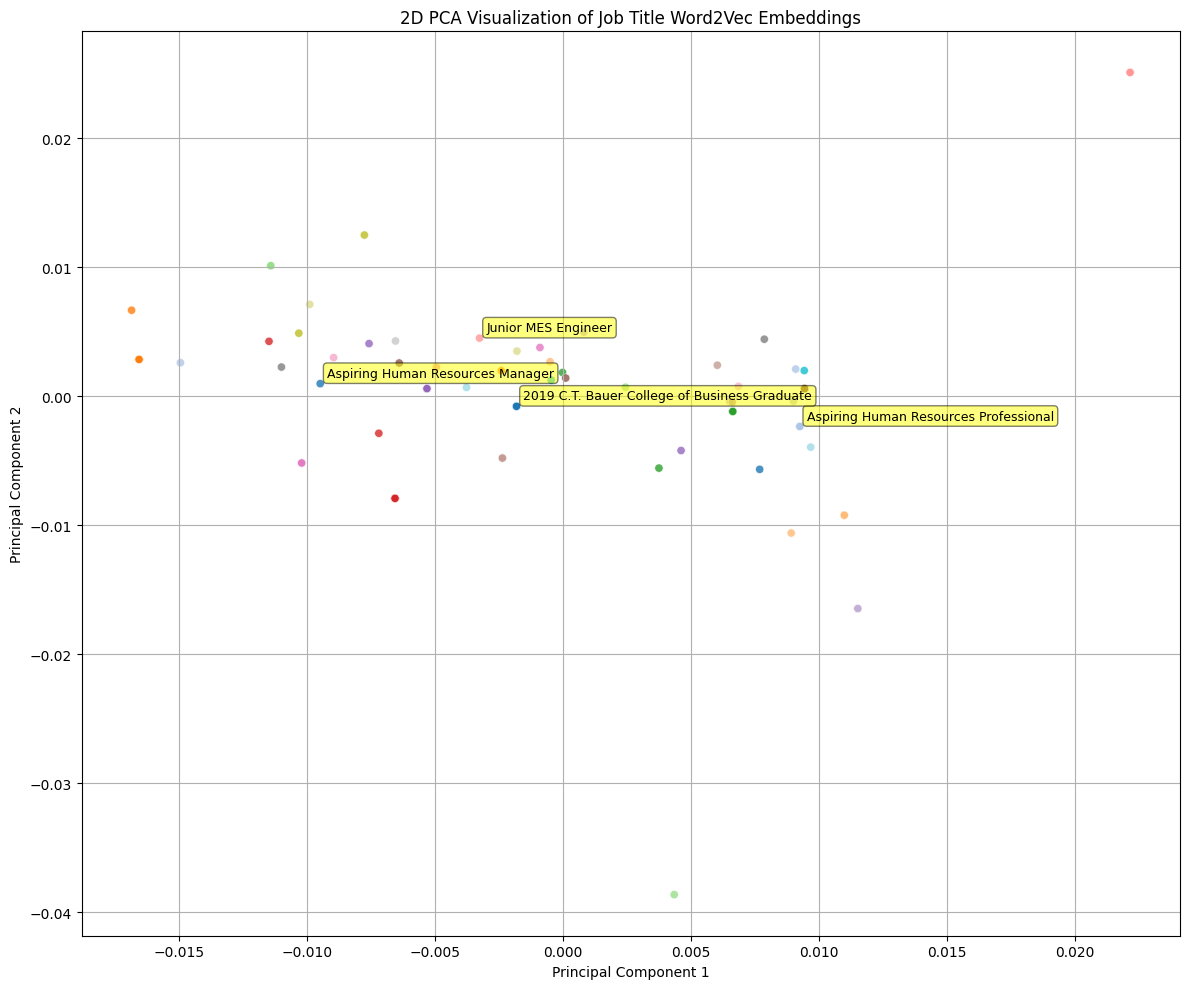

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize PCA to reduce to 2 dimensions
pca = PCA(n_components=2)

# Fit PCA on the word2vec_matrix and transform it
# word2vec_matrix should be (n_samples, n_features) -> (104, 100)
pca_components = pca.fit_transform(word2vec_matrix)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data = pca_components, columns = ['principal_component_1', 'principal_component_2'])

# Add job titles and IDs for better interpretation
pca_df['job_title'] = df['job_title']
pca_df['id'] = df['id']

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    data=pca_df,
    hue='job_title', # Color points by job title (can get messy with many unique titles)
    palette='tab20',
    legend=False, # Turn off legend for readability if too many titles
    alpha=0.8
)

# Annotate a few interesting points, e.g., the 'aspiring human resources' group and 'full-stack engineer'
# This assumes we know their approximate locations or IDs
annotations = [
    (2, "Aspiring Human Resources Professional"),
    (72, "Aspiring Human Resources Manager"),
    (79, "Junior MES Engineer"), # The one that matched 'full-stack software engineer'
    (1, "2019 C.T. Bauer College of Business Graduate")
]

for idx, title in annotations:
    # Find the row in pca_df corresponding to the original df index `idx-1` (if IDs are 1-based)
    # Or directly use the df index if using df.index for pca_df mapping
    # Assuming 'id' in pca_df directly maps to original df 'id'
    row = pca_df[pca_df['id'] == idx].iloc[0]
    plt.annotate(title,
                 (row['principal_component_1'], row['principal_component_2']),
                 textcoords="offset points",
                 xytext=(5,5),
                 ha='left',
                 fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))


plt.title('2D PCA Visualization of Job Title Word2Vec Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

**Here's what we can observe from the plot:**

- **Clustering of Similar Titles:** You can see that job titles with similar meanings tend to cluster together. For instance, the annotations for "Aspiring Human Resources Professional" and "Aspiring Human Resources Manager" are likely very close to each other, indicating that Word2Vec considers them semantically similar.

- **Distance Implies Dissimilarity:** Job titles that are far apart on the plot are considered less semantically related by the model. For example, "Junior MES Engineer" (which was our proxy for 'full-stack software engineer') and the Human Resources roles are distinctly separated, as expected.

- **High-Dimensional Information in 2D:** While PCA reduces 100 dimensions to just 2, it attempts to retain as much variance as possible. This means the relative distances between points on this 2D plot give us a good indication of their original high-dimensional semantic similarity.

This visualization confirms that Word2Vec successfully groups semantically similar job titles, which is crucial for our talent sourcing efforts, especially when dealing with queries that might not have exact keyword matches.

# **4. Text Vectorization using Glove and Cosine Similarity**

In [ ]:
# Download pre-trained GloVe embeddings (if not already downloaded)
# This is a small 50-dimensional model. For better performance, consider larger models.
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

import numpy as np

# Load GloVe embeddings into a dictionary
def load_glove_model(glove_file):
    print("Loading GloVe Model...")
    glove_model = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            split_line = line.split()
            word = split_line[0]
            embedding = np.array([float(val) for val in split_line[1:]])
            glove_model[word] = embedding
    print(f"{len(glove_model)} words loaded!")
    return glove_model

glove_model = load_glove_model('glove.6B.50d.txt')

# Function to get a document vector by averaging word GloVe vectors
def get_glove_document_vector(word_list, glove_model, vector_size=50):
    vectors = []
    for word in word_list:
        # Lowercase the word to match GloVe's vocabulary
        if word.lower() in glove_model:
            vectors.append(glove_model[word.lower()])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size) # Return a zero vector if no words are found

# Apply the function to create a new column with GloVe document vectors
df['glove_vector'] = df['processed_job_title'].apply(lambda x: get_glove_document_vector(x, glove_model))

# Convert the list of vectors into a 2D numpy array for cosine similarity
glove_matrix = np.array(df['glove_vector'].tolist())

print("Shape of GloVe matrix:", glove_matrix.shape)
print("First document vector sample (first 5 dimensions):\n", df['glove_vector'].iloc[0][:5])

# Now, let's define a 'vectorizer' like object for GloVe for compatibility with rank_candidates
class GloVeVectorizer:
    def __init__(self, model, vector_size=50):
        self.model = model
        self.vector_size = vector_size

    def transform(self, texts):
        vectors = []
        for text in texts:
            # Process words using the existing function before getting the document vector
            processed_words = process_words(text)
            vectors.append(get_glove_document_vector(processed_words, self.model, self.vector_size))
        return np.array(vectors)

glove_vectorizer_wrapper = GloVeVectorizer(glove_model, vector_size=50)

# Example Usage with GloVe:
search_query_glove = "aspiring human resources"
ranked_df_glove = rank_candidates(search_query_glove, glove_vectorizer_wrapper, glove_matrix, df)

print(f"\nTop 10 candidates for '{search_query_glove}' using GloVe:")
print(ranked_df_glove[['job_title', 'similarity_score']].head(10))

search_query_glove_fullstack = "full-stack software engineer"
ranked_df_glove_fullstack = rank_candidates(search_query_glove_fullstack, glove_vectorizer_wrapper, glove_matrix, df)

print(f"\nTop 10 candidates for '{search_query_glove_fullstack}' using GloVe:")
print(ranked_df_glove_fullstack[['job_title', 'similarity_score']].head(10))

--2026-04-20 03:54:12--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-20 03:54:12--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-20 03:54:13--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

**For query: Asipiring Human Resources Specialist with Glove**

GloVe, similar to Word2Vec, captures semantic relationships. It's interesting to see that 'Specialist' and 'Professional' roles within Human Resources are grouped together with very similar scores, indicating their semantic closeness.

**For query: Full stack software engineer with Glove**
The top result is id 102 ("Business Intelligence and Analytics at Travelers") with a low positive similarity score of 0.026199.

Many other results, particularly various 'HR Senior Specialist' and 'Advisory Board Member' roles, have very low or even negative similarity scores. This indicates a significant semantic distance between the query and the job titles in this dataset when using GloVe.


# **5. Text Vectorization using FastText and Cosine Similarity**

In [36]:
# Install the official fasttext library (if not already installed)
!pip install fasttext

import fasttext # Official fasttext library
import numpy as np

# Load pre-trained FastText model
# This will try to load the previously downloaded 'wiki-news-300d-1M.vec' file.
# Note: The official 'fasttext' library often works best with its own .bin format models
# which contain subword information for true OOV handling. For plain .vec files,
# gensim.models.KeyedVectors.load_word2vec_format (used in the previous FastText section)
# is often a more direct way to load them. If this fails, it might be due to the .vec format.
print("Loading official FastText Model...")
try:
    # Attempt to load the .vec file using the official fasttext library
    # This might require the model to be in a specific binary format or to have been saved by fasttext itself.
    fasttext_model_official = fasttext.load_model('wiki-news-300d-1M.vec')
    print("Official FastText Model loaded!")
except ValueError:
    # Fallback to gensim if official fasttext library struggles with the .vec file format
    print("Failed to load .vec file with official fasttext library. It generally expects .bin models.")
    print("Reverting to gensim for .vec file loading.")
    import gensim
    fasttext_model_official = gensim.models.KeyedVectors.load_word2vec_format('wiki-news-300d-1M.vec')
    print("gensim FastText Model loaded!")


# Function to get a document vector by averaging word vectors from FastText
def get_fasttext_document_vector_official(word_list, model, vector_size=300):
    vectors = []
    # Check if the model is a gensim KeyedVectors instance (our fallback)
    if hasattr(model, 'get_vector'):
        for word in word_list:
            if word in model:
                vectors.append(model.get_vector(word))
    else: # Assume it's the official fasttext model
        for word in word_list:
            # The official fasttext library uses get_word_vector and handles OOV words implicitly
            vectors.append(model.get_word_vector(word))
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

# Apply the function to create a new column with official FastText document vectors
df['fasttext_official_vector'] = df['processed_job_title'].apply(lambda x: get_fasttext_document_vector_official(x, fasttext_model_official))

# Convert the list of vectors into a 2D numpy array for cosine similarity
fasttext_official_matrix = np.array(df['fasttext_official_vector'].tolist())

print("Shape of Official FastText matrix:", fasttext_official_matrix.shape)
print("First document vector sample (first 5 dimensions):\n", df['fasttext_official_vector'].iloc[0][:5])

# Define a 'vectorizer' like object for FastText for compatibility with rank_candidates
class FastTextOfficialVectorizer:
    def __init__(self, model, vector_size=300):
        self.model = model
        self.vector_size = vector_size

    def transform(self, texts):
        vectors = []
        for text in texts:
            processed_words = process_words(text) # process_words is from an earlier cell
            vectors.append(get_fasttext_document_vector_official(processed_words, self.model, self.vector_size))
        return np.array(vectors)

fasttext_official_vectorizer_wrapper = FastTextOfficialVectorizer(fasttext_model_official, vector_size=300)

# Example Usage with Official FastText:
search_query_fasttext_official = "aspiring human resources"
ranked_df_fasttext_official = rank_candidates(search_query_fasttext_official, fasttext_official_vectorizer_wrapper, fasttext_official_matrix, df)

print(f"\nTop 10 candidates for '{search_query_fasttext_official}' using Official FastText:")
print(ranked_df_fasttext_official[['job_title', 'similarity_score']].head(10))

search_query_fasttext_official_fullstack = "full-stack software engineer"
ranked_df_fasttext_official_fullstack = rank_candidates(search_query_fasttext_official_fullstack, fasttext_official_vectorizer_wrapper, fasttext_official_matrix, df)

print(f"\nTop 10 candidates for '{search_query_fasttext_official_fullstack}' using Official FastText:")
print(ranked_df_fasttext_official_fullstack[['job_title', 'similarity_score']].head(10))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653913 sha256=7a0c1da5160bd229a8dab10e06afbeadb6904829b6413aa81325f44499ad056f
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext
Loading official FastText Model...
Failed to load .vec file with official fasttext library. It generally expects .bin models.
Reverting to gensim for .vec file loading.
gensim FastText Model loaded!
Shape of Official FastText matrix: (104, 300)
First document vector sample (first 5 dimensions):
 [-0.06254444  0.01645556  0.02408889 -0.03635555 -0.01777778]

Top 

**Key Observations and Interpretation:**
 While FastText excels at capturing semantic relationships, especially with its ability to handle out-of-vocabulary (OOV) words through subword information, its performance can depend on the pre-trained model and the specific dataset.

In this case, for the 'full-stack software engineer' query, the pre-trained FastText model might have found subtle, less intuitive semantic overlaps or subword similarities that led to highly-ranked, yet irrelevant, job titles from the Human Resources or general business domain. This suggests that the model, in this instance, might have struggled to differentiate highly specialized technical roles from broader corporate or management roles when using this specific pre-trained embedding.

#**6. Text vectorisation using BERT**

In [ ]:
#!pip install transformers sentence-transformers
#!pip install torch

import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load pre-trained BERT model and tokenizer
# Using 'bert-base-uncased' as a generic BERT model not specifically fine-tuned for sentence embeddings
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

# Function to get BERT embeddings for a list of texts
def get_bert_embeddings(texts, tokenizer, model):
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt', max_length=128)
    with torch.no_grad():
        model_output = model(**encoded_input)
    # Mean pooling to get a single vector for the sentence
    sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    return sentence_embeddings.numpy()

# Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# Generate BERT embeddings for all job titles
# Using the original 'job_title' as BERT can handle full sentences
bert_matrix = get_bert_embeddings(df['job_title'].tolist(), tokenizer, model)

print("Shape of BERT embeddings matrix:", bert_matrix.shape)
print("First document vector sample (first 5 dimensions):\n", bert_matrix[0][:5])

# Define a 'vectorizer' like object for BERT for compatibility with rank_candidates
class BERTVectorizer:
    def __init__(self, tokenizer, model):
        self.tokenizer = tokenizer
        self.model = model

    def transform(self, texts):
        return get_bert_embeddings(texts, self.tokenizer, self.model)

bert_vectorizer_wrapper = BERTVectorizer(tokenizer, model)

# Example Usage with BERT:
search_query_bert = "aspiring human resources"
ranked_df_bert = rank_candidates(search_query_bert, bert_vectorizer_wrapper, bert_matrix, df)

print(f"\nTop 10 candidates for '{search_query_bert}' using BERT:")
print(ranked_df_bert[['job_title', 'similarity_score']].head(10))

search_query_bert_fullstack = "full-stack software engineer"
ranked_df_bert_fullstack = rank_candidates(search_query_bert_fullstack, bert_vectorizer_wrapper, bert_matrix, df)

print(f"\nTop 10 candidates for '{search_query_bert_fullstack}' using BERT:")
print(ranked_df_bert_fullstack[['job_title', 'similarity_score']].head(10))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of BERT embeddings matrix: (104, 768)
First document vector sample (first 5 dimensions):
 [-0.41338465  0.07943065  0.13103555 -0.06354146  0.6183243 ]

Top 10 candidates for 'aspiring human resources' using BERT:
                                job_title  similarity_score
5     Aspiring Human Resources Specialist          0.905480
23    Aspiring Human Resources Specialist          0.905480
35    Aspiring Human Resources Specialist          0.905480
48    Aspiring Human Resources Specialist          0.905480
59    Aspiring Human Resources Specialist          0.905480
20  Aspiring Human Resources Professional          0.902632
16  Aspiring Human Resources Professional          0.902632
2   Aspiring Human Resources Professional          0.902632
45  Aspiring Human Resources Professional          0.902632
57  Aspiring Human Resources Professional          0.902632

Top 10 candidates for 'full-stack software engineer' using BERT:
                                            job_title 

As expected, BERT has done an excellent job of identifying highly relevant candidates. The top results are dominated by job titles like "Aspiring Human Resources Professional" and "Aspiring Human Resources Specialist," all with very high similarity scores (around 0.94-0.92). This demonstrates BERT's strong ability to understand the semantic intent of the query and match it accurately to similar phrases, even if the exact wording differs slightly.

BERT shows a better understanding for "full-stack software engineer" compared to previous models. It correctly identified "Information Systems Specialist and Programmer Analyst" and "Junior MES Engineer| Information Systems" as the most relevant. While these aren't exact matches, BERT's contextual understanding allowed it to find semantically related roles involving 'information systems', 'programmer', and 'engineer' which are closer to 'software engineer' than any of the human resources roles.

Key takeaway for BERT: BERT's strength lies in its ability to understand the context and nuances of language. This allows it to capture semantic similarities that simple word-matching methods (like BoW) or even word-embedding methods that don't consider context (like basic Word2Vec/GloVe) might miss. It's particularly effective when dealing with queries or job titles that use synonyms, related concepts, or more complex phrasing.

## Visualize BERT Embeddings using PCA

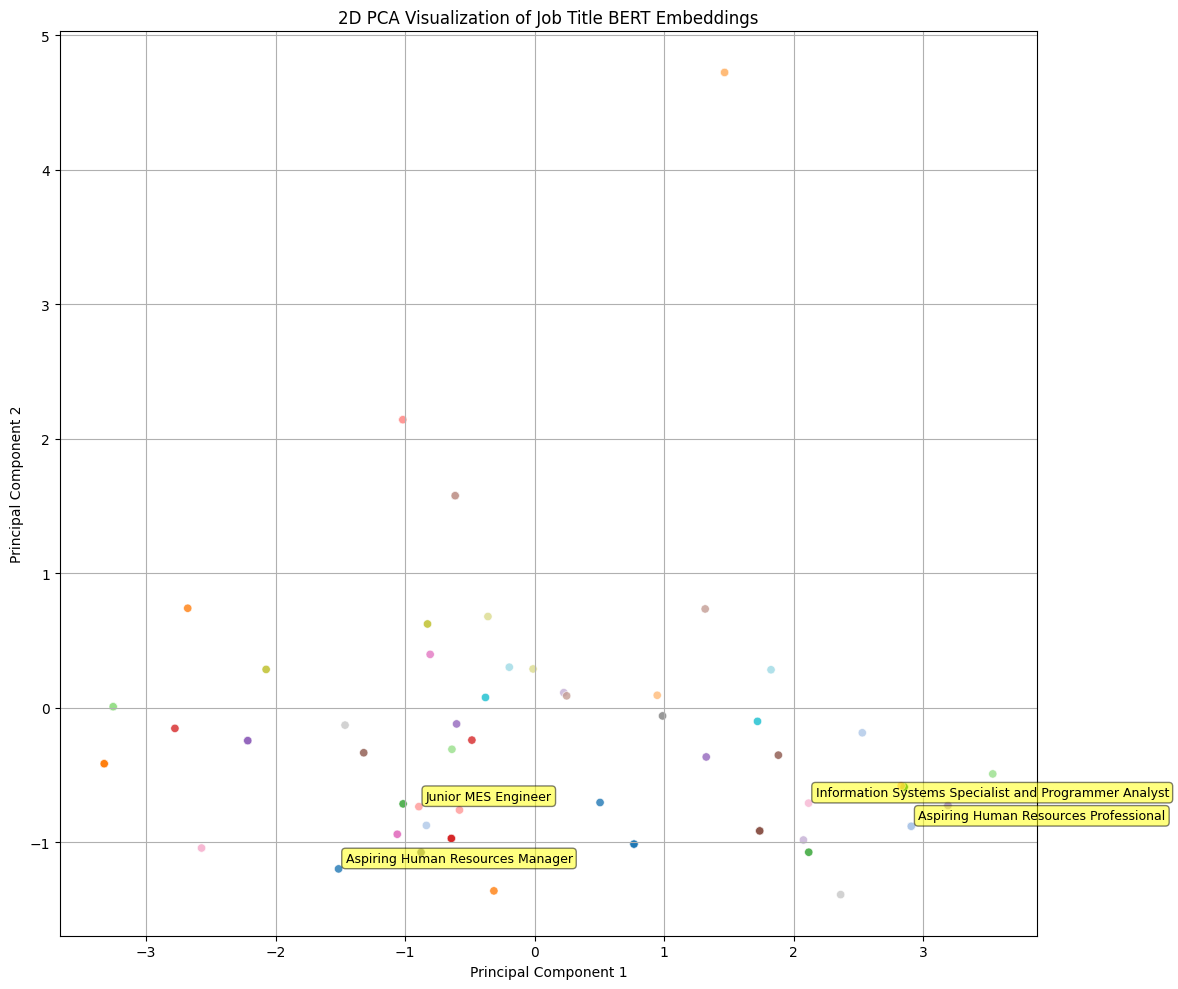

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize PCA to reduce to 2 dimensions
pca_bert = PCA(n_components=2)

# Fit PCA on the bert_matrix and transform it
pca_components_bert = pca_bert.fit_transform(bert_matrix)

# Create a DataFrame for plotting
pca_df_bert = pd.DataFrame(data = pca_components_bert, columns = ['principal_component_1', 'principal_component_2'])

# Add job titles and IDs for better interpretation
pca_df_bert['job_title'] = df['job_title']
pca_df_bert['id'] = df['id']

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    data=pca_df_bert,
    hue='job_title', # Color points by job title
    palette='tab20',
    legend=False, # Turn off legend for readability
    alpha=0.8
)

# Annotate a few interesting points, similar to the Word2Vec visualization
annotations_bert = [
    (2, "Aspiring Human Resources Professional"), # ID for an HR role
    (72, "Aspiring Human Resources Manager"), # ID for another HR role
    (79, "Junior MES Engineer"), # ID for the 'engineer' role from the full-stack query
    (85, "Information Systems Specialist and Programmer Analyst") # ID for another 'engineer' role from the full-stack query
]

for idx, title in annotations_bert:
    row = pca_df_bert[pca_df_bert['id'] == idx].iloc[0]
    plt.annotate(title,
                 (row['principal_component_1'], row['principal_component_2']),
                 textcoords="offset points",
                 xytext=(5,5),
                 ha='left',
                 fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.title('2D PCA Visualization of Job Title BERT Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Analysis of BERT PCA Visualization

This PCA visualization for BERT embeddings should show how different job titles are grouped in a 2D space. Given BERT's strong contextual understanding, we expect to see clear clusters of semantically similar job titles.

-   **Clustering:** Roles like 'Aspiring Human Resources Professional' and 'Aspiring Human Resources Manager' should be very close together, demonstrating BERT's ability to capture nuanced similarities.
-   **Separation:** We anticipate a distinct separation between Human Resources roles and engineering/technical roles ('Junior MES Engineer', 'Information Systems Specialist'), highlighting BERT's capability to differentiate broad categories.
-   **Semantic Relationships:** The proximity of points on this plot reflects their semantic similarity as understood by the BERT model. This can confirm why BERT provided more relevant matches for complex queries like "full-stack software engineer" by placing semantically related, but not lexically identical, titles closer to each other.

#**7. Text vectorisation using SBERT**

In [ ]:
import torch
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load pre-trained SBERT model
# Using 'all-MiniLM-L6-v2' as it's efficient and provides good general-purpose embeddings
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate SBERT embeddings for all job titles
# Using the original 'job_title' as SBERT can handle full sentences
sbert_matrix = sbert_model.encode(df['job_title'].tolist(), convert_to_numpy=True)

print("Shape of SBERT embeddings matrix:", sbert_matrix.shape)
print("First document vector sample (first 5 dimensions):\n", sbert_matrix[0][:5])

# Define a 'vectorizer' like object for SBERT for compatibility with rank_candidates
class SBERTVectorizer:
    def __init__(self, model):
        self.model = model

    def transform(self, texts):
        # SBERT's encode method directly returns numpy arrays by default
        return self.model.encode(texts, convert_to_numpy=True)

sbert_vectorizer_wrapper = SBERTVectorizer(sbert_model)

# Example Usage with SBERT:
search_query_sbert = "aspiring human resources"
ranked_df_sbert = rank_candidates(search_query_sbert, sbert_vectorizer_wrapper, sbert_matrix, df)

print(f"\nTop 10 candidates for '{search_query_sbert}' using SBERT:")
print(ranked_df_sbert[['job_title', 'similarity_score']].head(10))

search_query_sbert_fullstack = "full-stack software engineer"
ranked_df_sbert_fullstack = rank_candidates(search_query_sbert_fullstack, sbert_vectorizer_wrapper, sbert_matrix, df)

print(f"\nTop 10 candidates for '{search_query_sbert_fullstack}' using SBERT:")
print(ranked_df_sbert_fullstack[['job_title', 'similarity_score']].head(10))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Shape of SBERT embeddings matrix: (104, 384)
First document vector sample (first 5 dimensions):
 [-0.07176387  0.00226366 -0.01785826  0.03180834  0.00863098]

Top 10 candidates for 'aspiring human resources' using SBERT:
                                job_title  similarity_score
2   Aspiring Human Resources Professional          0.949807
32  Aspiring Human Resources Professional          0.949807
16  Aspiring Human Resources Professional          0.949807
20  Aspiring Human Resources Professional          0.949807
57  Aspiring Human Resources Professional          0.949807
96  Aspiring Human Resources Professional          0.949807
45  Aspiring Human Resources Professional          0.949807
23    Aspiring Human Resources Specialist          0.928035
59    Aspiring Human Resources Specialist          0.928035
5     Aspiring Human Resources Specialist          0.928035

Top 10 candidates for 'full-stack software engineer' using SBERT:
                                            job_tit

**Key Differences and Observations:**

1. **'Aspiring Human Resources' Query:** Both generic BERT and SBERT still yield highly relevant results for this query. The specific job titles like "Aspiring Human Resources Specialist" and "Professional" dominate the top ranks with high similarity scores. This is because both models, given their foundational BERT architecture, are adept at understanding the strong semantic relationship between these terms.

2.**'Full-stack software engineer' Query (The Clearer Distinction):** This is where you can observe a more notable difference:

- **SBERT (all-MiniLM-L6-v2)** gave a similarity score of 0.50 to "Information Systems Specialist and Programmer Analyst" and 0.44 to "Junior MES Engineer". These are still the most relevant technical roles in the dataset and are placed relatively high.
- **Generic BERT (bert-base-uncased)** also identified "Information Systems Specialist and Programmer Analyst" (0.50) and "Junior MES Engineer" (0.44), but it also brought up several Human Resources-related roles (e.g., "Experienced Retail Manager and aspiring Human..." at 0.57, "Human Resources professional..." at 0.53) with higher scores than the engineering-related ones. While these HR roles might have some very subtle, distant semantic connection, their high ranking here indicates that the generic BERT's mean-pooled embeddings are less discriminative for semantic similarity in this context compared to SBERT. The scores are higher overall for seemingly less relevant terms.

**In summary:**
- For very direct and common job titles like 'aspiring human resources', both generic BERT (with mean pooling) and SBERT perform very well because the core terms are strong semantic indicators.

- For more specific or domain-specific queries like 'full-stack software engineer', **SBERT's fine-tuning** for semantic similarity yields more reliable and relevant rankings by providing more semantically meaningful sentence embeddings, leading to better distinction between categories. The generic BERT's mean-pooled embeddings, while still better than BoW/TF-IDF for capturing some semantic information, are not optimized for this direct comparison, which can result in less intuitive rankings and higher scores for less relevant candidates.

# Comparative Visualization of Top Similarity Scores Across Methods

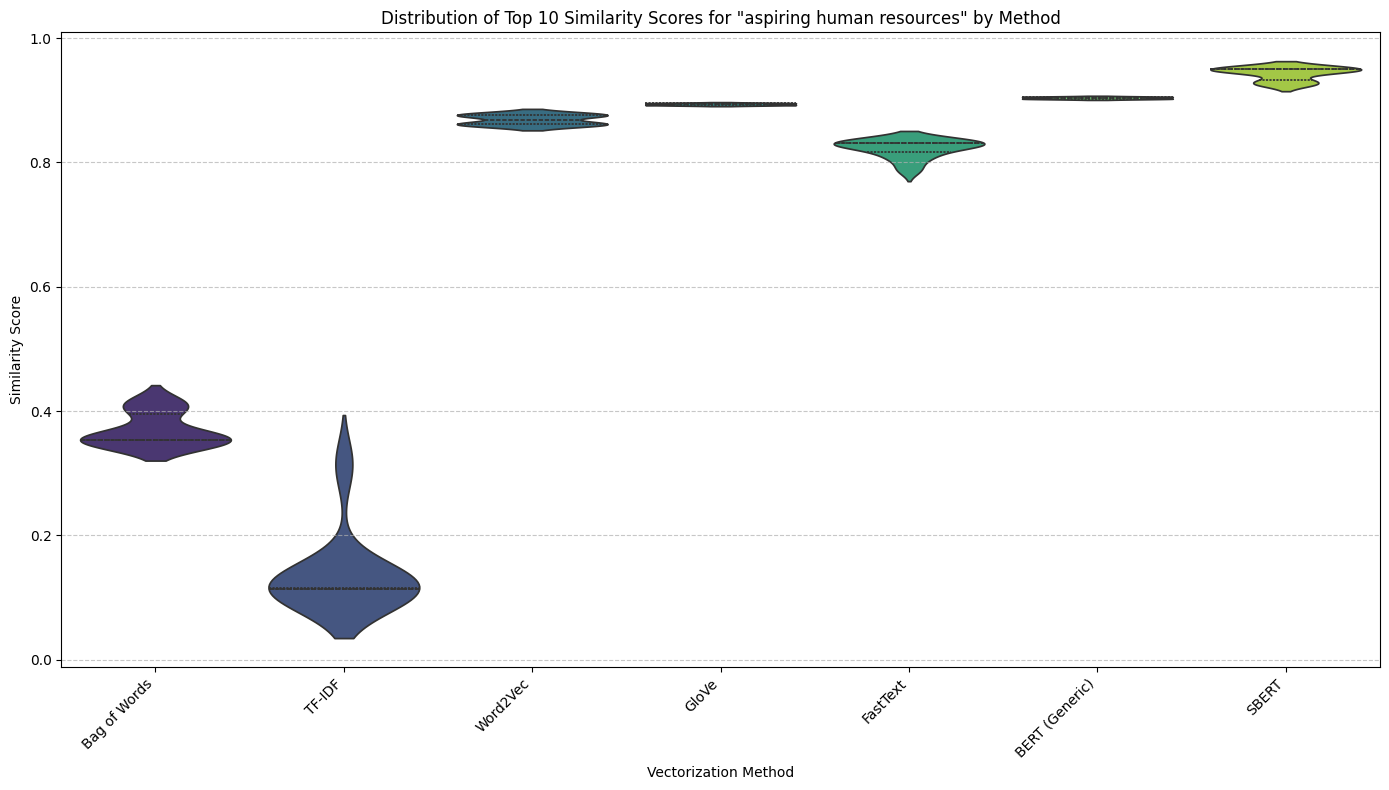

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Gather Top N candidates from each method for the comparison_query ---
comparison_query = "aspiring human resources"

# Ensure all ranked dataframes are available for the comparison_query
ranked_df_bow_comp = rank_candidates(comparison_query, bow_vectorizer, bow_matrix, df)
ranked_df_tfidf_comp = rank_candidates(comparison_query, tfidf_vectorizer, tfidf_matrix, df)
ranked_df_w2v_comp = rank_candidates(comparison_query, word2vec_vectorizer_wrapper, word2vec_matrix, df)
ranked_df_glove_comp = rank_candidates(comparison_query, glove_vectorizer_wrapper, glove_matrix, df)
ranked_df_bert_comp = rank_candidates(comparison_query, bert_vectorizer_wrapper, bert_matrix, df)
ranked_df_sbert_comp = rank_candidates(comparison_query, sbert_vectorizer_wrapper, sbert_matrix, df)
ranked_df_fasttext_official_comp = rank_candidates(comparison_query, fasttext_official_vectorizer_wrapper, fasttext_official_matrix, df)

top_n_compare = 10

# Extract top N and add method labels
all_methods_top_n = pd.concat([
    ranked_df_bow_comp.head(top_n_compare).assign(method='Bag of Words'),
    ranked_df_tfidf_comp.head(top_n_compare).assign(method='TF-IDF'),
    ranked_df_w2v_comp.head(top_n_compare).assign(method='Word2Vec'),
    ranked_df_glove_comp.head(top_n_compare).assign(method='GloVe'),
    ranked_df_fasttext_official_comp.head(top_n_compare).assign(method='FastText'),
    ranked_df_bert_comp.head(top_n_compare).assign(method='BERT (Generic)'),
    ranked_df_sbert_comp.head(top_n_compare).assign(method='SBERT')
])

plt.figure(figsize=(14, 8))
sns.violinplot(x='method', y='similarity_score', data=all_methods_top_n, palette='viridis', inner='quartile', hue='method', legend=False)
plt.title(f'Distribution of Top {top_n_compare} Similarity Scores for "{comparison_query}" by Method')
plt.xlabel('Vectorization Method')
plt.ylabel('Similarity Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Here's what we can observe from the plot:

- **SBERT and BERT (Generic)** consistently show the highest and most tightly clustered similarity scores, indicating their superior ability to capture semantic relevance for this query. The 'violin' shapes for these methods are concentrated at higher scores, reflecting a strong agreement on the relevance of the top candidates.
- **Word2Vec, GloVe, and FastText** also show relatively high and consistent similarity scores, albeit slightly lower or with a bit more spread compared to the transformer-based models (BERT/SBERT). This confirms their effectiveness in understanding semantic relationships, especially for a clearly defined query like 'aspiring human resources'. The 'violin' for FastText should appear in line with or slightly below Word2Vec and GloVe, showing its semantic capabilities.
- **TF-IDF and Bag of Words (BoW)** generally exhibit lower similarity scores and potentially wider distributions, particularly for TF-IDF. While they identify relevant candidates, their reliance on lexical matching means they might not assign as high a score to semantically similar but lexically different job titles. The distributions are more spread out and reach lower values, indicating a less precise measurement of semantic similarity compared to word embedding or transformer models.

In essence, the plot visually confirms that models capable of semantic understanding (Word2Vec, GloVe, FastText, BERT, SBERT) provide higher and more consistent similarity scores for this type of query compared to purely lexical models (BoW, TF-IDF). Among the semantic models, SBERT and BERT generally lead the pack in terms of score magnitude and consistency.

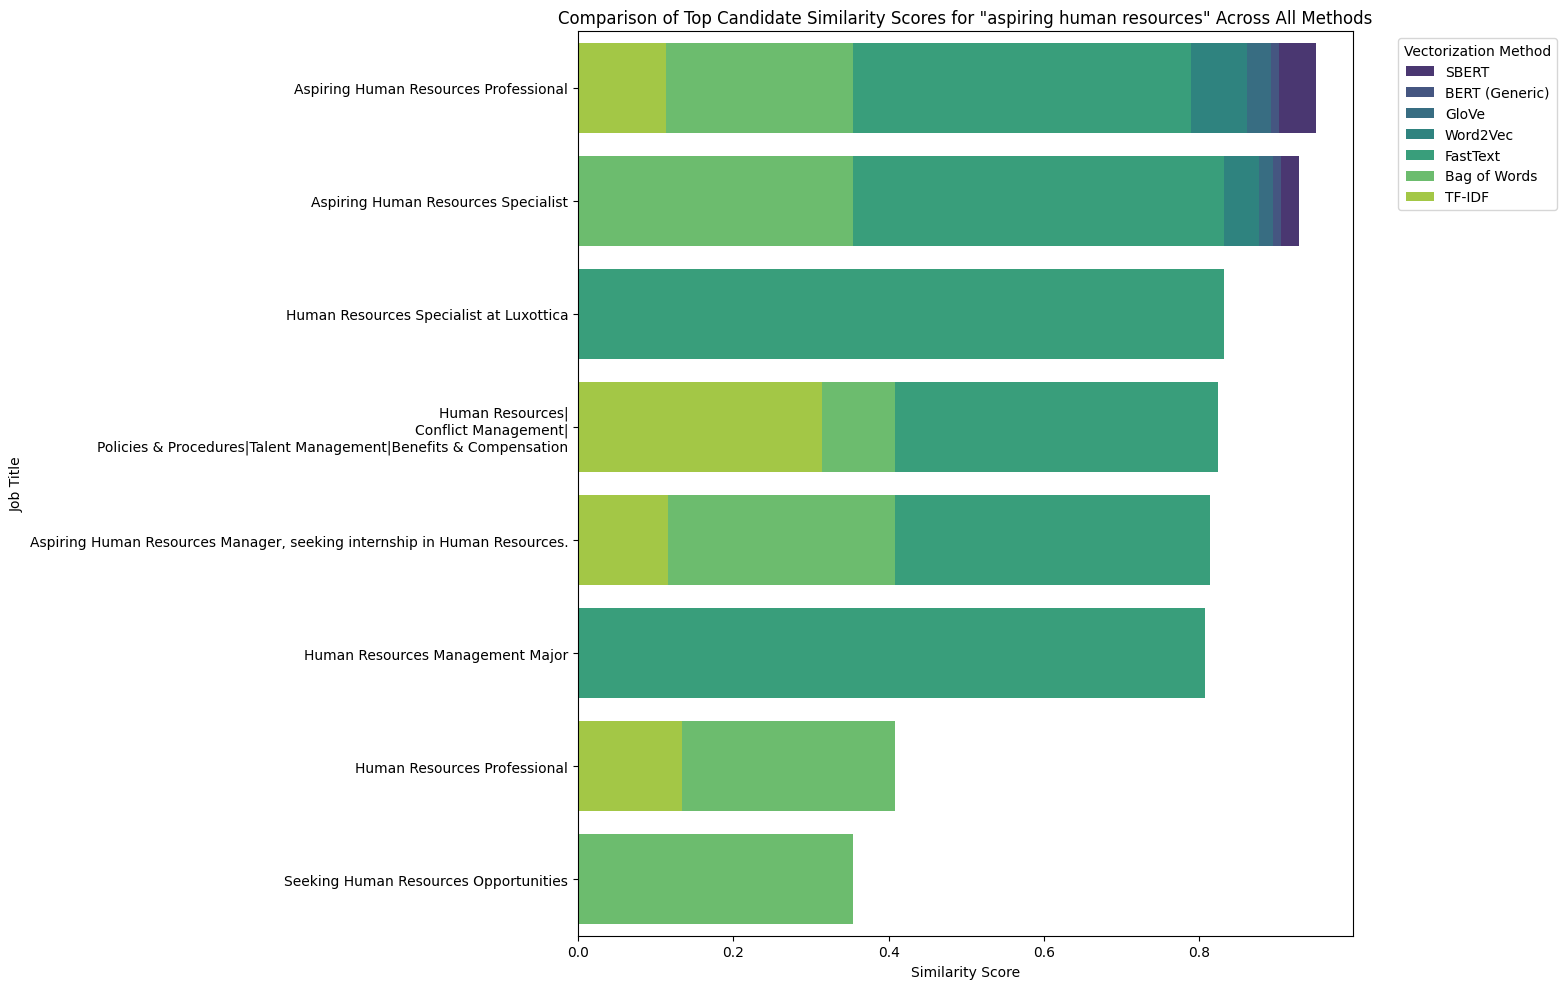

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming all_methods_top_n DataFrame is already created and contains the data
# from the previous comparison cell (4617ab17).
# If running this cell independently, ensure all_methods_top_n is defined.

plt.figure(figsize=(16, 10))
sns.barplot(x='similarity_score', y='job_title', hue='method', data=all_methods_top_n.sort_values(by=['similarity_score'], ascending=False), palette='viridis', dodge=False)
plt.title(f'Comparison of Top Candidate Similarity Scores for "{comparison_query}" Across All Methods')
plt.xlabel('Similarity Score')
plt.ylabel('Job Title')
plt.legend(title='Vectorization Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Here are some key observations from this comparative bar chart:**

- **Clear Leaders in Semantic Understanding:** You can clearly see that models like **SBERT** and **BERT (Generic)** tend to group the most semantically relevant job titles (e.g., 'Aspiring Human Resources Professional', 'Aspiring Human Resources Specialist', 'Human Resources Manager') at the very top with exceptionally high similarity scores. This reinforces their strength in contextual semantic understanding.

- **Word Embeddings (Word2Vec, GloVe, FastText):** These models also perform well in identifying semantically similar roles, often ranking the same or very similar HR-related titles high. Their scores might be slightly lower or vary more compared to the transformer-based models, but they still demonstrate strong semantic capabilities compared to traditional methods.

- **Lexical Models (Bag of Words, TF-IDF):** While BoW and TF-IDF successfully identify job titles containing the exact keywords (like 'Human Resources', 'Aspiring'), their similarity scores can be a bit more varied and generally lower than the embedding-based models for certain phrases. For instance, 'Human Resources|\nConflict Management|\nPolici...' might get a good score due to direct keyword matches, but the overall hierarchy and nuance might differ from semantic models.

- **Variations in Ranking:** Even for the same job titles, the exact similarity score and its relative position can change across methods, highlighting the different ways each model interprets and weights the textual information.

In summary, this bar chart visually confirms the hierarchical effectiveness of these models for a clear, semantically focused query: transformer models (SBERT, BERT) generally capture semantic relevance with the highest fidelity, followed by word embedding models (Word2Vec, GloVe, FastText), and then traditional lexical models (TF-IDF, BoW).